## Task 4

In [2]:
import Consumer as cs
import Government as gv

from types import SimpleNamespace
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

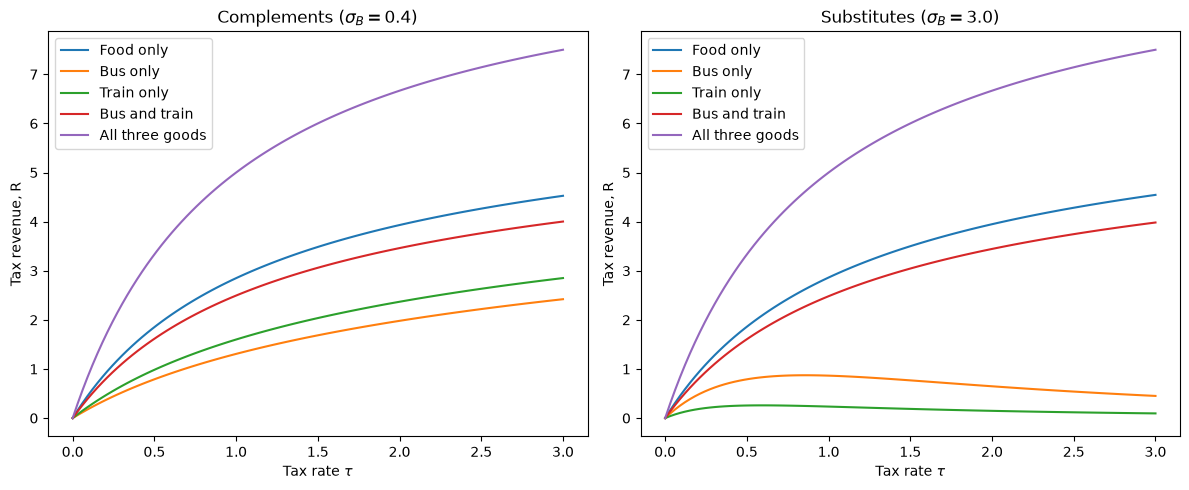

In [3]:
models = {
    'Complements ($\\sigma_B=0.4$)': gv.GovernmentClass(),
    'Substitutes ($\\sigma_B=3.0$)': gv.GovernmentClass(par={'sigma_B':3.0}),
}

instruments = {
    'Food only': (1,),
    'Bus only': (2,),
    'Train only': (3,),
    'Bus and train': (2,3),
    'All three goods': (1,2,3),
}

tau_vec = np.linspace(0,3,100)

fig,axes = plt.subplots(1,2,figsize=(12,5))

for ax,(calib_name,model) in zip(axes,models.items()):
    for label,goods in instruments.items():
        R_vec = np.empty(tau_vec.size)
        for i,tau in enumerate(tau_vec):
            R,u = model.revenue_and_utility(tau,goods=goods)
            R_vec[i] = R
        ax.plot(tau_vec,R_vec,label=label)
    ax.set_title(calib_name)
    ax.set_xlabel(r'Tax rate $\tau$')
    ax.set_ylabel('Tax revenue, R')
    ax.legend()

fig.tight_layout()
plt.show()